In [1]:
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import skfuzzy as fuzz
import torch
import torch.nn as nn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# -----------------------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

HAS_CUDA = torch.cuda.is_available()
if HAS_CUDA:
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

/home/nazanin/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:

# -----------------------------------------------------------------------------
# Dataset helpers
# -----------------------------------------------------------------------------
@dataclass
class CircleDataset:
    X_train: np.ndarray
    X_test: np.ndarray
    y_train_oh: np.ndarray
    y_test_oh: np.ndarray
    y_train_labels: np.ndarray
    y_test_labels: np.ndarray


def build_circles_dataset(n_samples: int = 2000, noise: float = 0.05) -> CircleDataset:
    X, y = make_circles(n_samples=n_samples, factor=0.4, noise=noise, random_state=SEED)
    scaler = StandardScaler()
    X = scaler.fit_transform(X).astype(np.float32)

    y_labels = y.astype(np.int64)
    y_one_hot = np.eye(2, dtype=np.float32)[y_labels]

    X_train, X_test, y_train_oh, y_test_oh = train_test_split(
        X,
        y_one_hot,
        test_size=0.3,
        random_state=SEED,
        stratify=y_labels,
    )

    y_train_labels = np.argmax(y_train_oh, axis=1)
    y_test_labels = np.argmax(y_test_oh, axis=1)

    return CircleDataset(
        X_train=X_train,
        X_test=X_test,
        y_train_oh=y_train_oh,
        y_test_oh=y_test_oh,
        y_train_labels=y_train_labels,
        y_test_labels=y_test_labels,
    )

In [4]:
# -----------------------------------------------------------------------------
# Fuzzy C-Means initialization
# -----------------------------------------------------------------------------
def fcm_initialize(X: np.ndarray, K: int, m: float = 2.0):
    """
    Run FCM to get rule antecedent prototypes.
    Args:
        X: (N, n_inputs) numpy array
        K: number of clusters/rules
        m: fuzziness parameter
    Returns:
        centers: (K, n_inputs)
        spreads: (K, n_inputs)
    """
    X_t = X.T  # (n_inputs, N)
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_t,
        c=K,
        m=m,
        error=1e-5,
        maxiter=2000,
        init=None,
    )
    N = X.shape[0]

    spreads = []
    for k in range(K):
        weights = u[k].reshape(N, 1)
        diff = X - cntr[k]
        denom = np.sum(weights) + 1e-12
        var = np.sum(weights * (diff**2), axis=0) / denom
        spreads.append(np.sqrt(np.clip(var, 1e-6, None)))

    return np.array(cntr, dtype=np.float32), np.array(spreads, dtype=np.float32)


In [5]:
# -----------------------------------------------------------------------------
# Simple Gaussian membership (FCM initialized)
# -----------------------------------------------------------------------------
class SimpleGaussianMF(nn.Module):
    def __init__(self, centers_init, spreads_init):
        """Standard Gaussian MFs initialized from FCM prototypes."""
        super().__init__()
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]

        self.centers = nn.Parameter(torch.tensor(centers_init, dtype=torch.float32))
        self.spreads = nn.Parameter(torch.tensor(spreads_init, dtype=torch.float32))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_exp = x.unsqueeze(1)  # (batch, 1, n_inputs)
        c_exp = self.centers.unsqueeze(0)  # (1, K, n_inputs)
        spreads = torch.abs(self.spreads).unsqueeze(0) + 1e-6

        mu = torch.exp(-((x_exp - c_exp) ** 2) / (2.0 * (spreads**2)))
        firing = torch.prod(mu, dim=2)
        return firing


# -----------------------------------------------------------------------------
# ANFIS classifier head
# -----------------------------------------------------------------------------
class ANFIS_BlendMFClassifier(nn.Module):
    def __init__(self, centers_init, spreads_init, n_outputs: int):
        super().__init__()
        self.mf_layer = SimpleGaussianMF(centers_init, spreads_init)
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]
        self.n_outputs = n_outputs

        # consequents per rule: (K, n_inputs + 1, n_outputs) -> last row is bias
        self.consequents = nn.Parameter(
            torch.randn(self.K, self.n_inputs + 1, self.n_outputs, dtype=torch.float32) * 0.1
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = self.mf_layer(x)  # (batch, K)
        w_sum = torch.sum(w, dim=1, keepdim=True) + 1e-8
        w_norm = w / w_sum

        weights = self.consequents[:, :-1, :]  # (K, n_inputs, n_outputs)
        bias = self.consequents[:, -1, :]  # (K, n_outputs)

        # Apply rule-wise linear consequents: einsum avoids awkward broadcasting
        linear = torch.einsum("bi,kio->bko", x, weights)
        rule_outputs = linear + bias.unsqueeze(0)  # (batch, K, n_outputs)

        y_pred = torch.sum(w_norm.unsqueeze(-1) * rule_outputs, dim=1)  # (batch, n_outputs)
        return y_pred  # logits; apply sigmoid externally when needed

Epoch 0001/1200  Train Loss 0.6880  Test Loss 0.6860  Train Acc 0.603  Test Acc 0.610
Epoch 0200/1200  Train Loss 0.5480  Test Loss 0.5486  Train Acc 0.982  Test Acc 0.987
Epoch 0400/1200  Train Loss 0.3547  Test Loss 0.3549  Train Acc 1.000  Test Acc 1.000
Epoch 0600/1200  Train Loss 0.2349  Test Loss 0.2352  Train Acc 1.000  Test Acc 1.000
Epoch 0800/1200  Train Loss 0.1736  Test Loss 0.1746  Train Acc 1.000  Test Acc 1.000
Epoch 1000/1200  Train Loss 0.1349  Test Loss 0.1363  Train Acc 1.000  Test Acc 1.000
Epoch 1200/1200  Train Loss 0.1083  Test Loss 0.1097  Train Acc 1.000  Test Acc 1.000

Final results (best checkpoint):
Train accuracy: 1.000
Test accuracy:  1.000
Test RMSE:      0.1144


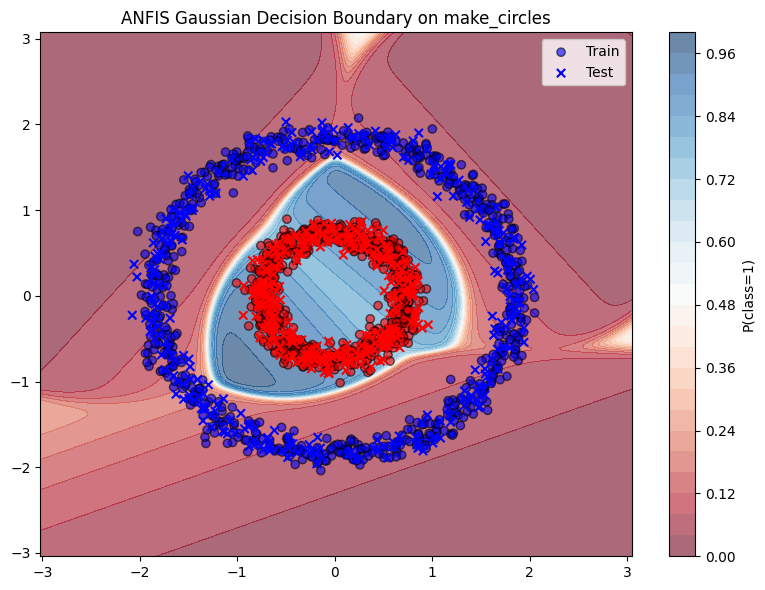

In [6]:
# -----------------------------------------------------------------------------
# Training and evaluation utilities
# -----------------------------------------------------------------------------
def evaluate(model, x_tensor, y_tensor):
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.sigmoid(logits)
        preds = torch.argmax(probs, dim=1)
        targets = torch.argmax(y_tensor, dim=1)
        acc = (preds == targets).float().mean().item()
        loss = torch.nn.functional.binary_cross_entropy(probs, y_tensor)
    return loss.item(), acc, probs


def main():
    device = torch.device("cuda" if HAS_CUDA else "cpu")
    data = build_circles_dataset()

    centers_init, spreads_init = fcm_initialize(data.X_train, K=6)

    X_train_tensor = torch.from_numpy(data.X_train).to(device)
    X_test_tensor = torch.from_numpy(data.X_test).to(device)
    y_train_tensor = torch.from_numpy(data.y_train_oh).to(device)
    y_test_tensor = torch.from_numpy(data.y_test_oh).to(device)

    model = ANFIS_BlendMFClassifier(
        centers_init=centers_init,
        spreads_init=spreads_init,
        n_outputs=2,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    best_state = None
    best_val = float("inf")
    n_epochs = 1200

    for epoch in range(1, n_epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_tensor)
        loss = criterion(logits, y_train_tensor)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        with torch.no_grad():
            model.eval()
            train_loss = criterion(model(X_train_tensor), y_train_tensor).item()
            test_loss = criterion(model(X_test_tensor), y_test_tensor).item()

        if test_loss < best_val:
            best_val = test_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 200 == 0 or epoch == 1:
            train_probs = torch.sigmoid(model(X_train_tensor))
            test_probs = torch.sigmoid(model(X_test_tensor))
            train_preds = torch.argmax(train_probs, dim=1).cpu().numpy()
            test_preds = torch.argmax(test_probs, dim=1).cpu().numpy()
            train_acc = np.mean(train_preds == data.y_train_labels)
            test_acc = np.mean(test_preds == data.y_test_labels)
            print(
                f"Epoch {epoch:04d}/{n_epochs}  "
                f"Train Loss {train_loss:.4f}  Test Loss {test_loss:.4f}  "
                f"Train Acc {train_acc:.3f}  Test Acc {test_acc:.3f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        train_logits = model(X_train_tensor)
        test_logits = model(X_test_tensor)
        train_probs = torch.sigmoid(train_logits).cpu().numpy()
        test_probs = torch.sigmoid(test_logits).cpu().numpy()

    train_pred = np.argmax(train_probs, axis=1)
    test_pred = np.argmax(test_probs, axis=1)

    train_acc = np.mean(train_pred == data.y_train_labels)
    test_acc = np.mean(test_pred == data.y_test_labels)
    test_rmse = np.sqrt(np.mean((test_probs - data.y_test_oh) ** 2))

    print("\nFinal results (best checkpoint):")
    print(f"Train accuracy: {train_acc:.3f}")
    print(f"Test accuracy:  {test_acc:.3f}")
    print(f"Test RMSE:      {test_rmse:.4f}")

    # -----------------------------------------------------------------------------
    # Visualization
    # -----------------------------------------------------------------------------
    xx, yy = np.meshgrid(
        np.linspace(data.X_train[:, 0].min() - 1.0, data.X_train[:, 0].max() + 1.0, 250),
        np.linspace(data.X_train[:, 1].min() - 1.0, data.X_train[:, 1].max() + 1.0, 250),
    )
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    grid_tensor = torch.from_numpy(grid).to(device)
    with torch.no_grad():
        grid_probs = torch.sigmoid(model(grid_tensor))[:, 1].cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, grid_probs, levels=30, cmap="RdBu", alpha=0.6)
    plt.colorbar(label="P(class=1)")
    plt.scatter(
        data.X_train[:, 0],
        data.X_train[:, 1],
        c=data.y_train_labels,
        cmap="bwr",
        edgecolor="k",
        alpha=0.6,
        label="Train",
    )
    plt.scatter(
        data.X_test[:, 0],
        data.X_test[:, 1],
        c=data.y_test_labels,
        cmap="bwr",
        marker="x",
        label="Test",
    )
    plt.title("ANFIS Gaussian Decision Boundary on make_circles")
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

